# Natural Gas Prices

After asking around for the source of the existing data, you learn that the current process is to take a monthly snapshot of prices from a market data provider, which represents the market price of natural gas delivered at the end of each calendar month. This data is available for roughly the next 18 months and is combined with historical prices in a time series database. After gaining access, you are able to download the data in a CSV file.

You should use this monthly snapshot to produce a varying picture of the existing price data, as well as an extrapolation for an extra year, in case the client needs an indicative price for a longer-term storage contract.

Download the monthly natural gas price data.
Each point in the data set corresponds to the purchase price of natural gas at the end of a month, from 31st October 2020 to 30th September 2024.
Analyze the data to estimate the purchase price of gas at any date in the past and extrapolate it for one year into the future.
Your code should take a date as input and return a price estimate.
Try to visualize the data to find patterns and consider what factors might cause the price of natural gas to vary. This can include looking at months of the year for seasonal trends that affect the prices, but market holidays, weekends, and bank holidays need not be accounted for.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from typing import Optional

In [14]:
def load_and_prepare_data(csv_path):
    """Load, parse, and prepare the monthly natural gas price data."""
    data = pd.read_csv(csv_path)
    data["Date"] = pd.to_datetime(data["Date"], format="%m/%d/%y")
    data.set_index("Date", inplace=True)
    data = data.sort_index()
    data = data.resample("M").mean()  # Fill any missing months safely
    data = data.dropna()
    return data

In [15]:
def fit_holt_winters(data, months):
    """Fit Holt-Winters model and forecast next 12 months."""
    if len(data) < 24:
        raise ValueError(
            "At least 24 months of data required for seasonal Holt-Winters model."
        )
    model = ExponentialSmoothing(
        data["Price"], trend="add", seasonal="add", seasonal_periods=12
    )
    fit = model.fit()
    forecast = fit.forecast(months)
    forecast_df = forecast.to_frame(name="Price")
    return forecast_df

In [16]:
def combine_and_interpolate(data, forecast_df):
    """Combine historical and forecasted data, interpolate to daily resolution."""
    full_data = pd.concat([data, forecast_df])
    full_daily = full_data.resample("D").interpolate(method="linear")
    return full_daily

In [17]:
def estimate_price(date_input, full_daily):
    """
    Estimate the natural gas price for any date using interpolated values.

    Args:
        date_input (str or datetime): Date for which to estimate price.

    Returns:
        float: Estimated price (interpolated if needed), or np.nan if out of range.
    """
    date = pd.to_datetime(date_input)
    if date in full_daily.index:
        return full_daily.loc[date, "Price"]
    elif full_daily.index.min() <= date <= full_daily.index.max():
        return np.interp(
            date.timestamp(),
            full_daily.index.astype(np.int64) // 10**9,
            full_daily["Price"].values,
        )
    else:
        return np.nan

In [18]:
def plot_prices(data, forecast, full_daily):
    """Plot historical, forecasted, and interpolated daily prices."""
    plt.figure(figsize=(10, 6))
    plt.plot(data.index, data["Price"], label="Historical Prices", marker="o")
    plt.plot(
        forecast.index,
        forecast["Price"],
        label="12-Month Forecast",
        marker="x",
        color="green",
    )
    plt.plot(
        full_daily.index,
        full_daily["Price"],
        label="Interpolated Daily Estimate",
        alpha=0.3,
        color="gray",
    )
    plt.title("Natural Gas Prices: Holt-Winters Forecast with Interpolation")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

Great work! The desk now has the price data they need. The final ingredient before they can begin trading with the client is the pricing model. Alex tells you the client wants to start trading as soon as possible. They believe the winter will be colder than expected, so they want to buy gas now to store and sell in winter in order to take advantage of the resulting increase in gas prices. They ask you to write a script that they can use to price the contract. Once the desk are happy, you will work with engineering, risk, and model validation to incorporate this model into production code.

The concept is simple: any trade agreement is as valuable as the price you can sell minus the price at which you are able to buy. Any cost incurred as part of executing this agreement is also deducted from the overall value. So, for example, if I can purchase a million MMBtu of natural gas in summer at $2/MMBtu, store this for four months, and ensure that I can sell the same quantity at $3/MMBtu without incurring any additional costs, the value of this contract would be ($3-$2) *1e6 = $1million. If there are costs involved, such as having to pay the storage facility owner a fixed fee of $100K a month, then the 'value' of the contract, from my perspective, would drop by the overall rental amount to $600K. Another cost could be the injection/withdrawal cost, like having to pay the storage facility owner $10K per 1 million MMBtu for injection/withdrawal, then the price will further go down by $10K to $590K. Additionally, if I am supposed to foot a bill of $50K each time for transporting the gas to and from the facility, the cost of this contract would fall by another $100K. Think of the valuation as a fair estimate at which both the trading desk and the client would be happy to enter into the contract.

You need to create a prototype pricing model that can go through further validation and testing before being put into production. Eventually, this model may be the basis for fully automated quoting to clients, but for now, the desk will use it with manual oversight to explore options with the client. 

You should write a function that is able to use the data you created previously to price the contract. The client may want to choose multiple dates to inject and withdraw a set amount of gas, so your approach should generalize the explanation from before. Consider all the cash flows involved in the product.

The input parameters that should be taken into account for pricing are:

Injection dates. 
Withdrawal dates.
The prices at which the commodity can be purchased/sold on those dates.
The rate at which the gas can be injected/withdrawn.
The maximum volume that can be stored.
Storage costs.
Write a function that takes these inputs and gives back the value of the contract. You can assume there is no transport delay and that interest rates are zero. Market holidays, weekends, and bank holidays need not be accounted for. Test your code by selecting a few sample inputs.

In [19]:
def price_storage_contract(
    full_daily: pd.DataFrame,
    injection_dates: list,
    withdrawal_dates: list,
    injection_volumes: list,
    withdrawal_volumes: list,
    storage_cost_per_month: float = 0.0,
    injection_cost_per_unit: float = 0.0,
    withdrawal_cost_per_unit: float = 0.0,
    max_storage: Optional[float] = None,
) -> float:
    """
    Price a natural gas storage contract given injection/withdrawal schedules and costs.

    Args:
        full_daily (pd.DataFrame): DataFrame indexed by date with a "Price" column.
        injection_dates (list): Dates (str or pd.Timestamp) for gas injection.
        withdrawal_dates (list): Dates (str or pd.Timestamp) for gas withdrawal.
        injection_volumes (list): Volumes injected on each injection date.
        withdrawal_volumes (list): Volumes withdrawn on each withdrawal date.
        storage_cost_per_month (float): Monthly storage cost (total, not per unit).
        injection_cost_per_unit (float): Cost per unit injected.
        withdrawal_cost_per_unit (float): Cost per unit withdrawn.
        max_storage (float): Maximum storage capacity (optional).

    Returns:
        float: The net value of the contract.
    """
    # Convert dates to pd.Timestamp for consistency
    injection_dates = pd.to_datetime(injection_dates)
    withdrawal_dates = pd.to_datetime(withdrawal_dates)

    # Track storage level over time
    storage_level = 0
    storage_timeline = {}

    # Cash flows
    total_injection_cost = 0
    total_withdrawal_revenue = 0
    total_injection_fee = 0
    total_withdrawal_fee = 0

    # Handle injections
    for date, vol in zip(injection_dates, injection_volumes):
        price = full_daily.loc[date, "Price"]
        total_injection_cost += price * vol
        total_injection_fee += injection_cost_per_unit * vol
        storage_level += vol
        storage_timeline[date] = storage_level
        if max_storage is not None and storage_level > max_storage:
            raise ValueError("Storage capacity exceeded on injection.")

    # Handle withdrawals
    for date, vol in zip(withdrawal_dates, withdrawal_volumes):
        price = full_daily.loc[date, "Price"]
        total_withdrawal_revenue += price * vol
        total_withdrawal_fee += withdrawal_cost_per_unit * vol
        storage_level -= vol
        storage_timeline[date] = storage_level
        if storage_level < 0:
            raise ValueError("Withdrawing more gas than stored.")

    # Storage cost: count unique months between first injection and last withdrawal
    if len(injection_dates) > 0 and len(withdrawal_dates) > 0:
        start = min(injection_dates.min(), withdrawal_dates.min())
        end = max(injection_dates.max(), withdrawal_dates.max())
        months = pd.period_range(start, end, freq="M").size
    else:
        months = 0
    total_storage_cost = months * storage_cost_per_month

    # Net contract value
    contract_value = (
        total_withdrawal_revenue
        - total_injection_cost
        - total_storage_cost
        - total_injection_fee
        - total_withdrawal_fee
    )
    return contract_value

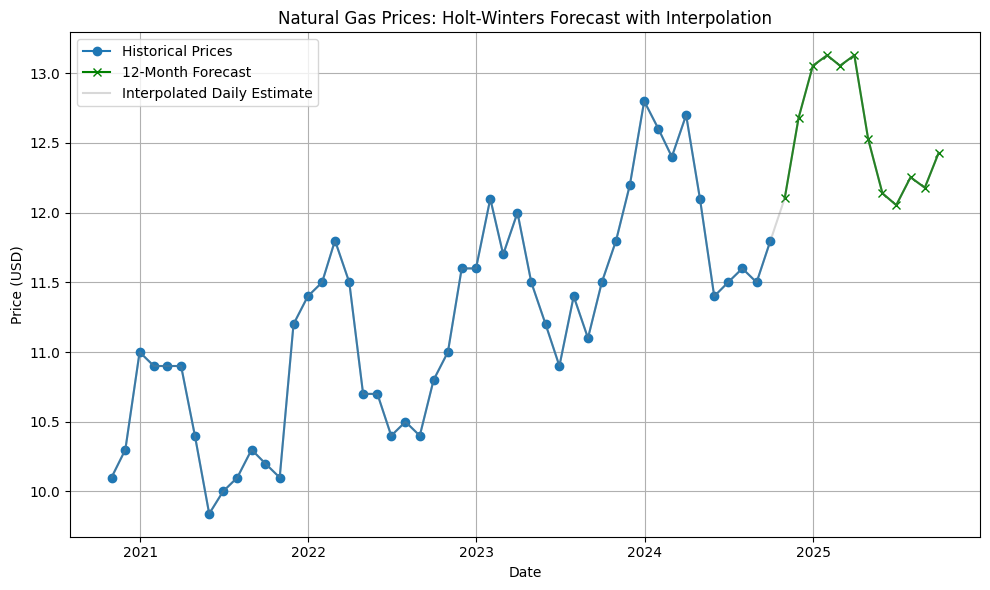

Estimated price on 2023-11-15: $12.00
Estimated price on 2025-05-15: $12.34
Contract value: $-19,320,483.87


In [20]:
data = load_and_prepare_data("natural_gas_prices.csv")
forecast_df = fit_holt_winters(data, 12)  # Forecast next 12 months
full_daily = combine_and_interpolate(data, forecast_df)
plot_prices(data, forecast_df, full_daily)

# Example usage
for test_date in [
    "2023-11-15",  # Within historical range
    "2025-05-15",  # Future date within forecast range
]:
    price = estimate_price(test_date, full_daily)
    print(f"Estimated price on {test_date}: ${price:.2f}")

# Example contract: inject in June/July, withdraw in Dec/Jan
value = price_storage_contract(
    full_daily,
    injection_dates=["2023-06-15", "2023-07-15"],
    withdrawal_dates=["2023-12-15", "2024-01-15"],
    injection_volumes=[500000, 500000],
    withdrawal_volumes=[600000, 400000],
    storage_cost_per_month=100000,
    injection_cost_per_unit=10,
    withdrawal_cost_per_unit=10,
    max_storage=1000000,
)
print(f"Contract value: ${value:,.2f}")